In [11]:
'''a one shot code to approximate 
the hsv values of the colors we're trying to detect in the image.

Manually selected the center of the cirlce to retrieve the coordinates using
apprximate_hsv_values.py

And reused the coord to get hsv values from the image
'''
import numpy as np
from skimage import io, color

base_image = io.imread("./seq1/001.png")

# Convert RGB image to HSV
hsv_image = color.rgb2hsv(base_image)

points = [[367.03246753, 381.64285714],
 [409.24025974, 380.01948052],
 [373.52597403, 412.48701299],
 [412.48701299, 407.61688312]]

print("Point (x, y) -> HSV values")
for x, y in points:
    row, col = int(round(y)), int(round(x))  # image indexing: row=y, col=x
    h, s, v = hsv_image[row, col]
    print(f"  ({x:.2f}, {y:.2f}) -> H={h:.4f}, S={s:.4f}, V={v:.4f}")


Point (x, y) -> HSV values
  (367.03, 381.64) -> H=0.3167, S=0.0429, V=0.9137
  (409.24, 380.02) -> H=0.3519, S=0.0388, V=0.9098
  (373.53, 412.49) -> H=0.4048, S=0.0314, V=0.8745
  (412.49, 407.62) -> H=0.5909, S=0.0474, V=0.9098


try to visualise the 'manully' detected colors to see if it makes sense

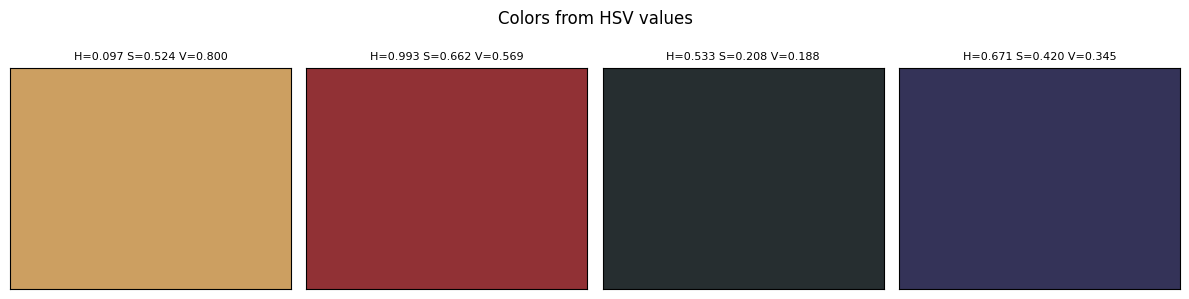

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage.color import hsv2rgb
import numpy as np

points = [[367.03246753, 381.64285714],
 [409.24025974, 380.01948052],
 [373.52597403, 412.48701299],
 [412.48701299, 407.61688312]]

H_TOL = 0.2
S_TOL = 0.02
V_TOL = 0.1

hsv_values = [
    (0.3167, 0.0429, 0.9137),
    (0.3519, 0.0388, 0.9098),
    (0.4048, 0.0314, 0.8745),
    (0.5909, 0.0474, 0.9098)
]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i, hsv in enumerate(hsv_values):
    rgb = hsv2rgb(np.array([[hsv]]))[0][0]  # shape (1,1,3) -> (3,)
    axes[i].add_patch(patches.Rectangle((0, 0), 1, 1, color=rgb))
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_title(f"H={hsv[0]:.3f} S={hsv[1]:.3f} V={hsv[2]:.3f}", fontsize=8)

plt.suptitle("Colors from HSV values", fontsize=12)
plt.tight_layout()
plt.show()

Apply a mask for each color to see if we can accurately detect the color circles in the image

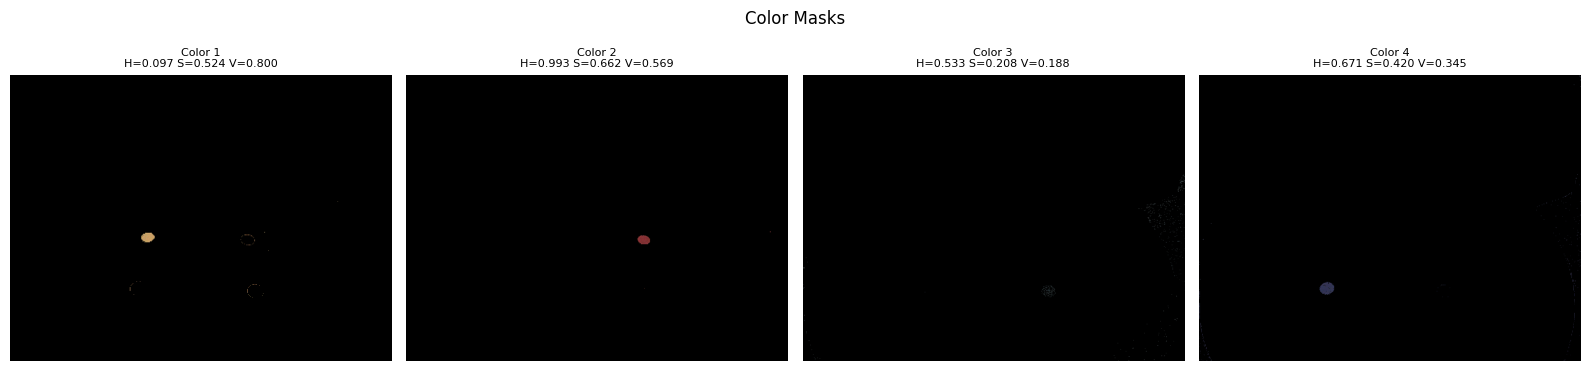

In [10]:
import numpy as np
from skimage import io, color
import matplotlib.pyplot as plt

base_image = io.imread("./seq1/001.png")
hsv_image = color.rgb2hsv(base_image)

hsv_values = [
    (0.0966, 0.5245, 0.8000), #yellow
    (0.9931, 0.6621, 0.5686), #red
    (0.5333, 0.2083, 0.1882), #green
    (0.6712, 0.4205, 0.3451) #blue
]

# Tolerance for each channel
H_TOL = 0.05
S_TOL = 0.15
V_TOL = 0.15

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, (h, s, v) in enumerate(hsv_values):

    # Build per-channel masks
    s_mask = (hsv_image[:, :, 1] >= s - S_TOL) & (hsv_image[:, :, 1] <= s + S_TOL)
    v_mask = (hsv_image[:, :, 2] >= v - V_TOL) & (hsv_image[:, :, 2] <= v + V_TOL)

    # Hue is circular, so handle wrap-around
    h_low, h_high = h - H_TOL, h + H_TOL
    if h_low < 0:
        h_mask = (hsv_image[:, :, 0] >= h_low + 1) | (hsv_image[:, :, 0] <= h_high)
    elif h_high > 1:
        h_mask = (hsv_image[:, :, 0] >= h_low) | (hsv_image[:, :, 0] <= h_high - 1)
    else:
        h_mask = (hsv_image[:, :, 0] >= h_low) & (hsv_image[:, :, 0] <= h_high)

    combined_mask = h_mask & s_mask & v_mask

    # Apply mask: keep original pixels where mask is True, else black
    masked_image = base_image[:, :, :3].copy()
    masked_image[~combined_mask] = 0

    axes[i].imshow(masked_image)
    axes[i].set_title(f"Color {i+1}\nH={h:.3f} S={s:.3f} V={v:.3f}", fontsize=8)
    axes[i].axis('off')

plt.suptitle("Color Masks", fontsize=12)
plt.tight_layout()
plt.show()